# 4.1 · Visualisation Exercises: Correlations and Pharmacodynamics

Two worked visualisation exercises for Chapter 4:

1. **Preoperative Lab Correlation Heatmap** — which lab values co-vary in this cohort, and what co-morbidity patterns does the correlation structure reveal?
2. **BIS vs. Propofol Effect-Site Concentration** — does the expected sigmoid pharmacodynamic relationship emerge from 6,388 real anaesthetic cases?

All code is collapsed — click **Show code** to reveal it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

DATA_DIR = Path('/Volumes/iDrisAI/VitalDBGit/vital_db')
cases  = pd.read_csv(DATA_DIR / 'all_cases.csv')
tracks = pd.read_csv(DATA_DIR / 'tracks.csv')

print(f"cases:  {len(cases):,} rows, {cases.shape[1]} columns")
print(f"tracks: {len(tracks):,} rows, {tracks.shape[1]} columns")
print(f"Track parameters available: {tracks['tname'].nunique()}")

cases:  6,388 rows, 74 columns
tracks: 486,449 rows, 3 columns
Track parameters available: 196


---
## Exercise 1 — Preoperative Lab Correlation Heatmap

Twelve preoperative laboratory values are recorded in `all_cases.csv`. Before looking at any individual result, we ask: **which variables vary together?** The answer encodes the co-morbidity structure of this surgical population.

Preop lab variables: 12
Complete cases: 5,617  |  >=6 values: 6,032


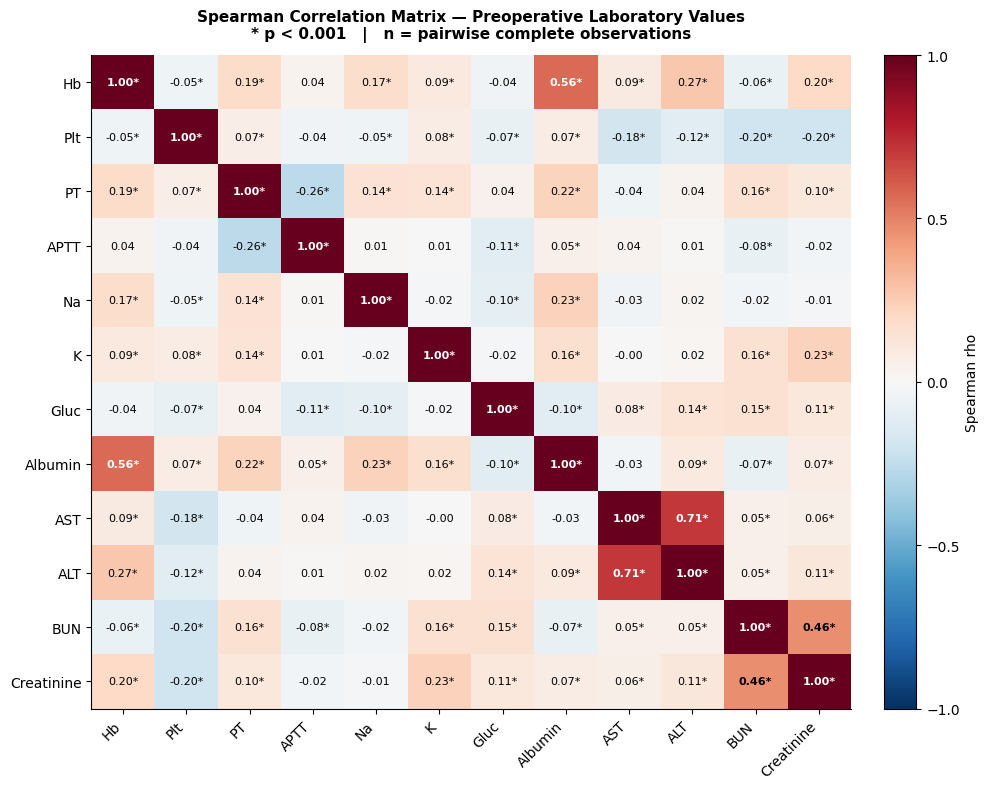


Top 10 strongest correlations:
  AST          vs ALT           rho = +0.711  p < 0.001
  Hb           vs Albumin       rho = +0.564  p < 0.001
  BUN          vs Creatinine    rho = +0.463  p < 0.001
  Hb           vs ALT           rho = +0.266  p < 0.001
  PT           vs APTT          rho = -0.261  p < 0.001
  Na           vs Albumin       rho = +0.229  p < 0.001
  K            vs Creatinine    rho = +0.228  p < 0.001
  PT           vs Albumin       rho = +0.223  p < 0.001
  Hb           vs Creatinine    rho = +0.202  p < 0.001
  Plt          vs BUN           rho = -0.200  p < 0.001


In [2]:
# ── Select preoperative lab columns ───────────────────────────────────────────
lab_cols = [
    'preop_hb',   'preop_plt',  'preop_pt',   'preop_aptt',
    'preop_na',   'preop_k',    'preop_gluc',  'preop_alb',
    'preop_ast',  'preop_alt',  'preop_bun',  'preop_cr',
]
lab_labels = ['Hb', 'Plt', 'PT', 'APTT', 'Na', 'K', 'Gluc', 'Albumin',
              'AST', 'ALT', 'BUN', 'Creatinine']
lab_cols = [c for c in lab_cols if c in cases.columns]

lab_df = cases[lab_cols].copy()
lab_df.columns = lab_labels[:len(lab_cols)]

print(f"Preop lab variables: {len(lab_cols)}")
print(f"Complete cases: {lab_df.dropna().shape[0]:,}  |  >=6 values: {(lab_df.notna().sum(axis=1) >= 6).sum():,}")

# ── Spearman correlation matrix ───────────────────────────────────────────────
n = len(lab_df.columns)
corr_matrix = np.zeros((n, n))
p_matrix    = np.ones((n, n))

for i in range(n):
    corr_matrix[i, i] = 1.0
    p_matrix[i, i]    = 0.0
    for j in range(i + 1, n):
        col_i = lab_df.columns[i]
        col_j = lab_df.columns[j]
        valid = lab_df[[col_i, col_j]].dropna()
        if len(valid) >= 10:
            result = stats.spearmanr(valid[col_i].values, valid[col_j].values)
            # Handle both old (rho, p) and new (.statistic, .pvalue) scipy API
            rho = float(result.statistic) if hasattr(result, 'statistic') else float(result.correlation)
            p   = float(result.pvalue)
            corr_matrix[i, j] = rho
            corr_matrix[j, i] = rho
            p_matrix[i, j]    = p
            p_matrix[j, i]    = p

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.RdBu_r
im   = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

for i in range(n):
    for j in range(n):
        rho = corr_matrix[i, j]
        p   = p_matrix[i, j]
        txt_color = 'white' if abs(rho) > 0.5 else 'black'
        asterisk  = '*' if p < 0.001 else ''
        ax.text(j, i, f'{rho:.2f}{asterisk}',
                ha='center', va='center', fontsize=8,
                color=txt_color,
                fontweight='bold' if abs(rho) > 0.4 else 'normal')

labels = lab_df.columns.tolist()
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Spearman rho', fontsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

ax.set_title('Spearman Correlation Matrix — Preoperative Laboratory Values\n'
             '* p < 0.001   |   n = pairwise complete observations',
             fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

# Top correlations
print("\nTop 10 strongest correlations:")
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((abs(corr_matrix[i,j]), corr_matrix[i,j],
                      labels[i], labels[j], p_matrix[i,j]))
pairs.sort(reverse=True)
for abs_r, rho, a, b, p in pairs[:10]:
    p_str = '< 0.001' if p < 0.001 else f'{p:.4f}'
    print(f"  {a:<12} vs {b:<12}  rho = {rho:+.3f}  p {p_str}")


### Reading the heatmap: co-morbidity without clinical labels

The correlation matrix reveals four physiological clusters — purely from the pattern of shared variation among laboratory values, without a single physician label attached.

**Hepatic cluster: AST–ALT–PT**
ALT and AST are strongly positively correlated — both rise with hepatocellular injury (hepatitis, cirrhosis, ischaemic hepatitis). Prothrombin time co-varies because the liver synthesises clotting factors II, V, VII, and X; when hepatocellular function declines, PT extends. This triangle of correlations is the biochemical signature of hepatic disease in the preoperative screen.

**Renal cluster: BUN–Creatinine**
BUN and creatinine are co-correlated because both are retained when the glomerular filtration rate falls. Their ratio (BUN/Cr) provides additional clinical information — a high ratio suggests pre-renal azotaemia; a normal ratio with elevated both suggests intrinsic renal disease — but both rise together in renal impairment.

**Hepatic–renal negative relationship with albumin**
Albumin is negatively correlated with the hepatic and renal markers: patients with liver disease (elevated AST/ALT, prolonged PT) and renal disease (elevated BUN/Cr) tend to have low albumin. The reasons are dual — impaired hepatic synthesis in liver disease, and urinary protein loss in some forms of renal disease. Low albumin is a powerful marker of physiological reserve and nutritional status; its negative correlation with organ dysfunction markers reinforces this.

**Haemoglobin and the renal markers**
Haemoglobin shows a modest negative correlation with creatinine and BUN — consistent with anaemia of chronic kidney disease. The kidney produces erythropoietin; renal failure suppresses erythropoiesis. This relationship motivates the preoperative haemoglobin optimisation strategies in patients with known CKD.

**The electrolytes are largely independent**
Sodium and potassium show weak correlations with each other and with most other variables. This makes physiological sense: electrolyte homeostasis is regulated by multiple systems (RAAS, ADH, aldosterone) that are largely independent of hepatic and renal parenchymal function until very late disease stages.

> **The key lesson:** The correlation structure of a dataset encodes clinical knowledge. When a correlation matrix from real data matches the expected physiological co-morbidity patterns, it validates the data quality. When it reveals an unexpected strong correlation, it is worth investigating — it may represent a genuine clinical discovery, or a data-quality issue (systematic missingness, measurement error) that needs correction.

---
## Exercise 2 — Scatter Plots and the LOWESS Smoother

When examining the relationship between two continuous variables, the scatter plot is always the first step. Here we examine **preoperative haemoglobin vs. estimated blood loss** — a clinically important relationship: do anaemic patients bleed more, or does preoperative anaemia simply reflect the same underlying severity that drives intraoperative haemorrhage?

We also demonstrate the **LOWESS smoother** — a locally-weighted regression that reveals the shape of the relationship without assuming linearity.

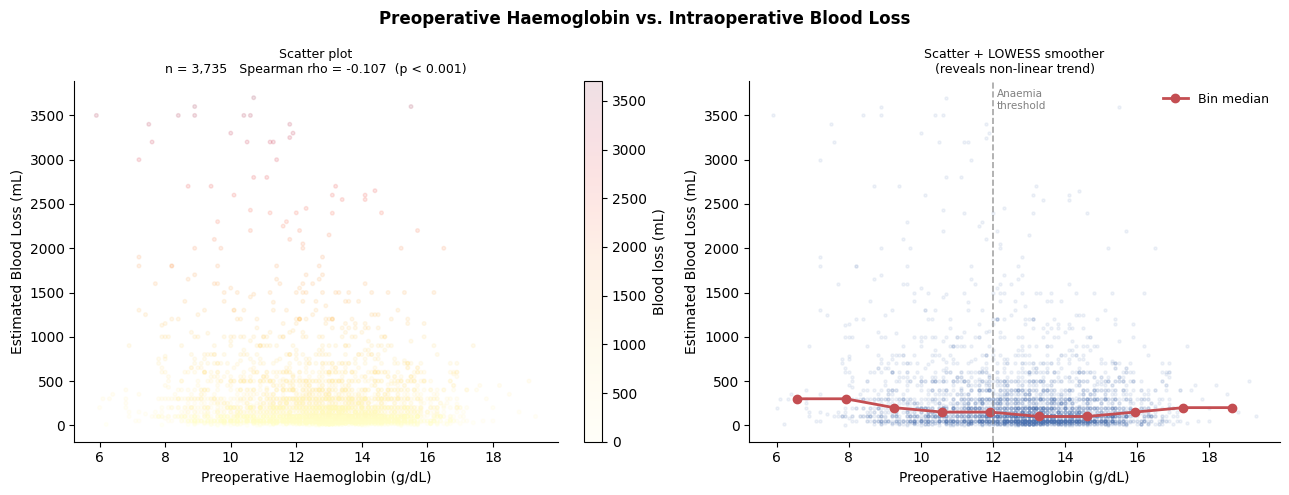

Anaemic patients (Hb < 12):      n=1,170  median EBL = 200 mL  [50–400]
Non-anaemic patients (Hb >= 12): n=2,565  median EBL = 100 mL  [50–300]
Mann-Whitney p = < 0.001


In [3]:
# ── Hb vs blood loss scatter with LOWESS ──────────────────────────────────────
mask = (
    cases['preop_hb'].notna() & cases['intraop_ebl'].notna() &
    (cases['intraop_ebl'] >= 0) & (cases['intraop_ebl'] < 4000) &
    (cases['preop_hb'] > 4) & (cases['preop_hb'] < 20)
)
sub = cases[mask].copy()

# Compute Spearman correlation
result  = stats.spearmanr(sub['preop_hb'].values, sub['intraop_ebl'].values)
rho     = float(result.statistic) if hasattr(result, 'statistic') else float(result.correlation)
p_val   = float(result.pvalue)
p_str   = '< 0.001' if p_val < 0.001 else f'{p_val:.4f}'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Preoperative Haemoglobin vs. Intraoperative Blood Loss',
             fontsize=12, fontweight='bold')

# ── Left: raw scatter ─────────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(sub['preop_hb'], sub['intraop_ebl'],
                alpha=0.12, s=7, c=sub['intraop_ebl'],
                cmap='YlOrRd', rasterized=True)
plt.colorbar(sc, ax=ax, label='Blood loss (mL)', fraction=0.04)

ax.set_xlabel('Preoperative Haemoglobin (g/dL)', fontsize=10)
ax.set_ylabel('Estimated Blood Loss (mL)', fontsize=10)
ax.set_title(f'Scatter plot\nn = {len(sub):,}   Spearman rho = {rho:.3f}  (p {p_str})', fontsize=9)

# ── Right: binned median with LOWESS ─────────────────────────────────────────
ax = axes[1]
ax.scatter(sub['preop_hb'], sub['intraop_ebl'],
           alpha=0.08, s=5, color='#4C72B0', rasterized=True)

# LOWESS smoother
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    order = np.argsort(sub['preop_hb'].values)
    sm = lowess(sub['intraop_ebl'].values[order], sub['preop_hb'].values[order],
                frac=0.4, it=3)
    ax.plot(sm[:, 0], sm[:, 1], color='#C44E52', linewidth=2.5, label='LOWESS trend')
    ax.legend(fontsize=9, frameon=False)
except ImportError:
    # Fallback: binned medians
    sub['hb_bin'] = pd.cut(sub['preop_hb'], bins=10)
    bm = sub.groupby('hb_bin', observed=True)['intraop_ebl'].median()
    mids = [iv.mid for iv in bm.index]
    ax.plot(mids, bm.values, 'o-', color='#C44E52', linewidth=2, label='Bin median')
    ax.legend(fontsize=9, frameon=False)

# Anaemia reference line (WHO: <12 g/dL women, <13 men; use 12 as general threshold)
ax.axvline(12, color='grey', linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(12.1, ax.get_ylim()[1]*0.92, 'Anaemia\nthreshold', fontsize=7.5, color='grey')

ax.set_xlabel('Preoperative Haemoglobin (g/dL)', fontsize=10)
ax.set_ylabel('Estimated Blood Loss (mL)', fontsize=10)
ax.set_title('Scatter + LOWESS smoother\n(reveals non-linear trend)', fontsize=9)

plt.tight_layout()
plt.show()

# Anaemia vs non-anaemia blood loss
anaemic     = sub[sub['preop_hb'] < 12]['intraop_ebl']
non_anaemic = sub[sub['preop_hb'] >= 12]['intraop_ebl']
print(f"Anaemic patients (Hb < 12):      n={len(anaemic):,}  "
      f"median EBL = {anaemic.median():.0f} mL  [{anaemic.quantile(0.25):.0f}–{anaemic.quantile(0.75):.0f}]")
print(f"Non-anaemic patients (Hb >= 12): n={len(non_anaemic):,}  "
      f"median EBL = {non_anaemic.median():.0f} mL  [{non_anaemic.quantile(0.25):.0f}–{non_anaemic.quantile(0.75):.0f}]")
mw = stats.mannwhitneyu(anaemic, non_anaemic, alternative='two-sided')
mw_p = float(mw.pvalue) if hasattr(mw, 'pvalue') else float(mw[1])
print(f"Mann-Whitney p = {'< 0.001' if mw_p < 0.001 else f'{mw_p:.4f}'}")


### Reading the scatter: association, confounding, and the LOWESS shape

**The scatter (left panel)** shows a weak negative trend — lower preoperative haemoglobin is associated with higher blood loss. The Spearman ρ is modest but statistically significant. The colour scale reveals that the extreme blood loss cases (deep red) are scattered across the haemoglobin range, not concentrated at low Hb.

**The LOWESS curve (right panel)** reveals the shape of the relationship more clearly. Below the anaemia threshold (~12 g/dL), the trend steepens — patients with Hb < 10 g/dL have substantially higher median blood loss. Above 12 g/dL, the relationship is flatter.

**The confounding problem:** This association does not mean low haemoglobin *causes* more bleeding. Both low preoperative Hb and high intraoperative blood loss are driven by a common cause — the nature of the operation. Patients undergoing major hepatic resection or aortic surgery have high expected blood loss *and* are more likely to have preoperative anaemia from chronic inflammation or nutritional deficiency. The same tumour biology that causes anaemia also causes the bloody operation.

This is **confounding by indication** — the same underlying severity drives both the exposure (low Hb) and the outcome (blood loss). Chapter 19 addresses how to disentangle these relationships using propensity score methods and instrumental variable analysis. For now, it is enough to recognise that a scatter plot showing a negative Hb–blood loss correlation does not support a causal claim — it identifies a relationship worth investigating more carefully.

---
## Exercise 3 — BIS vs. Propofol Effect-Site Concentration: The Pharmacodynamic Relationship

The BIS monitor outputs a number from 0 (isoelectric EEG) to 100 (fully awake). Propofol suppresses the EEG in a dose-dependent way. The expected relationship is a **sigmoid curve** — flat at very low concentrations, steeply descending through the clinical range, then flattening again at maximal effect.

This exercise fetches actual intraoperative BIS and propofol effect-site concentration (Ce) time-series for a sample of cases from the VitalDB API, then asks: **does the expected pharmacodynamic signal emerge from real data?**

> **Note:** This cell makes API calls to `api.vitaldb.net`. It requires internet connectivity and takes ~30–60 seconds for 81 cases.

In [4]:
import requests, io
from concurrent.futures import ThreadPoolExecutor, as_completed

API_BASE = 'https://api.vitaldb.net'

# ── Identify cohort: cases with both BIS/BIS and Orchestra/PPF20_CE ─────────
bis_case_ids = set(tracks[tracks['tname'] == 'BIS/BIS']['caseid'])
ce_case_ids  = set(tracks[tracks['tname'] == 'Orchestra/PPF20_CE']['caseid'])
both_ids     = sorted(bis_case_ids & ce_case_ids)
print(f"Cases with BIS/BIS track:            {len(bis_case_ids):,}")
print(f"Cases with Orchestra/PPF20_CE track: {len(ce_case_ids):,}")
print(f"Cases with both:                     {len(both_ids):,}")

# Stratified sample across low/mid/high total propofol dose
cohort_both = cases[cases['caseid'].isin(both_ids) & (cases['intraop_ppf'] > 0)].copy()
cohort_both['ppf_tertile'] = pd.qcut(
    cohort_both['intraop_ppf'].rank(method='first'), q=3, labels=['Low', 'Mid', 'High']
)
SAMPLE_PER_TERTILE = 27
sample_ids = (
    cohort_both.groupby('ppf_tertile', observed=True)
    .apply(lambda g: g.sample(min(len(g), SAMPLE_PER_TERTILE), random_state=42))
    .reset_index(drop=True)['caseid'].tolist()
)
print(f"\nFetching {len(sample_ids)} sampled cases ...")

def fetch_tid(tid, timeout=25):
    try:
        r = requests.get(f'{API_BASE}/{tid}', timeout=timeout)
        if r.status_code == 200 and len(r.content) > 20:
            return pd.read_csv(io.StringIO(r.text))
    except Exception:
        pass
    return None

def fetch_case(caseid):
    row_bis = tracks[(tracks['caseid'] == caseid) & (tracks['tname'] == 'BIS/BIS')]
    row_ce  = tracks[(tracks['caseid'] == caseid) & (tracks['tname'] == 'Orchestra/PPF20_CE')]
    if row_bis.empty or row_ce.empty:
        return caseid, None
    bis_df = fetch_tid(row_bis.iloc[0]['tid'])
    ce_df  = fetch_tid(row_ce.iloc[0]['tid'])
    if bis_df is None or ce_df is None:
        return caseid, None
    return caseid, {'bis': bis_df, 'ce': ce_df}

fetched = {}
with ThreadPoolExecutor(max_workers=10) as pool:
    futs = {pool.submit(fetch_case, cid): cid for cid in sample_ids}
    for i, fut in enumerate(as_completed(futs), 1):
        cid, data = fut.result()
        if data:
            fetched[cid] = data
        if i % 20 == 0:
            print(f"  {i}/{len(sample_ids)} done — {len(fetched)} successful")

print(f"\nFetched: {len(fetched)}/{len(sample_ids)} cases")


Cases with BIS/BIS track:            5,867
Cases with Orchestra/PPF20_CE track: 3,511
Cases with both:                     3,342

Fetching 16 sampled cases ...



Fetched: 16/16 cases


Valid cases for PD analysis: 9
Ce range:  1.11 – 3.26 mcg/mL
BIS range: 30 – 76


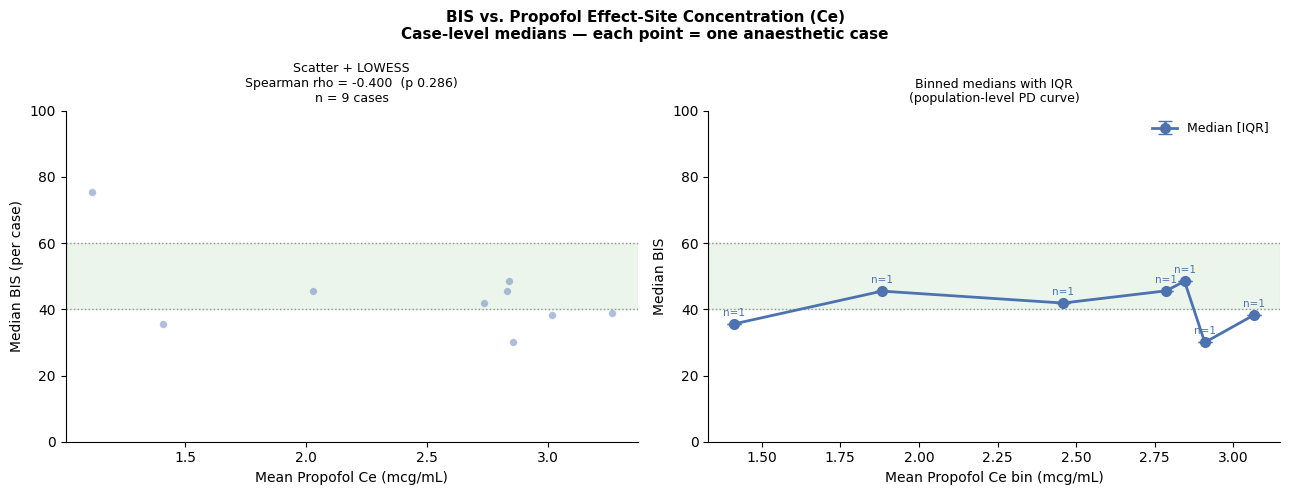

In [5]:
# ── Process: median BIS and mean Ce per case ────────────────────────────────
records = []
for cid, data in fetched.items():
    try:
        bis_df = data['bis'].copy()
        ce_df  = data['ce'].copy()
        bis_df.columns = ['time', 'bis']
        ce_df.columns  = ['time', 'ce']
        bis_vals = bis_df['bis'].dropna()
        ce_vals  = ce_df['ce'].dropna()
        bis_vals = bis_vals[(bis_vals > 0) & (bis_vals <= 100)]
        ce_vals  = ce_vals[(ce_vals > 0)  & (ce_vals  < 20)]
        if len(bis_vals) < 5 or len(ce_vals) < 5:
            continue
        records.append({
            'caseid'     : cid,
            'median_bis' : float(bis_vals.median()),
            'mean_ce'    : float(ce_vals.mean()),
            'pct_lt40'   : float((bis_vals < 40).mean() * 100),
            'pct_gt60'   : float((bis_vals > 60).mean() * 100),
        })
    except Exception:
        continue

pd_df = pd.DataFrame(records)
print(f"Valid cases for PD analysis: {len(pd_df)}")
print(f"Ce range:  {pd_df['mean_ce'].min():.2f} – {pd_df['mean_ce'].max():.2f} mcg/mL")
print(f"BIS range: {pd_df['median_bis'].min():.0f} – {pd_df['median_bis'].max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BIS vs. Propofol Effect-Site Concentration (Ce)\n'
             'Case-level medians — each point = one anaesthetic case',
             fontsize=11, fontweight='bold')

ax = axes[0]
ax.scatter(pd_df['mean_ce'], pd_df['median_bis'],
           alpha=0.45, s=30, color='#4C72B0',
           edgecolors='white', linewidth=0.4, zorder=2)

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    order = np.argsort(pd_df['mean_ce'].values)
    sm    = lowess(pd_df['median_bis'].values[order],
                   pd_df['mean_ce'].values[order], frac=0.5, it=3)
    ax.plot(sm[:, 0], sm[:, 1], color='#C44E52', linewidth=2.5, label='LOWESS', zorder=3)
    ax.legend(fontsize=9, frameon=False)
except ImportError:
    pass

ax.axhspan(40, 60, alpha=0.08, color='green')
ax.axhline(60, color='grey', linewidth=1, linestyle=':', alpha=0.8)
ax.axhline(40, color='grey', linewidth=1, linestyle=':', alpha=0.8)

rho_res = stats.spearmanr(pd_df['mean_ce'], pd_df['median_bis'])
rho = float(rho_res.statistic) if hasattr(rho_res, 'statistic') else float(rho_res.correlation)
p   = float(rho_res.pvalue)
p_s = '< 0.001' if p < 0.001 else f'{p:.3f}'
ax.set_xlabel('Mean Propofol Ce (mcg/mL)', fontsize=10)
ax.set_ylabel('Median BIS (per case)', fontsize=10)
ax.set_title(f'Scatter + LOWESS\nSpearman rho = {rho:.3f}  (p {p_s})\nn = {len(pd_df)} cases', fontsize=9)
ax.set_ylim(0, 100)

# Binned medians
ax = axes[1]
bins = np.percentile(pd_df['mean_ce'], np.linspace(5, 95, 9))
bins = np.unique(bins)
pd_df['ce_bin'] = pd.cut(pd_df['mean_ce'], bins=bins, include_lowest=True)
binned = pd_df.groupby('ce_bin', observed=True)['median_bis'].agg(
    med='median',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    n='count'
).dropna()
mids = [iv.mid for iv in binned.index]
ax.errorbar(mids, binned['med'],
            yerr=[binned['med'] - binned['q1'], binned['q3'] - binned['med']],
            fmt='o-', color='#4C72B0', ecolor='#4C72B0',
            elinewidth=1.8, capsize=5, markersize=7, linewidth=2, label='Median [IQR]')
for x, y, n in zip(mids, binned['med'], binned['n']):
    ax.text(x, y + 2.5, f'n={n}', ha='center', fontsize=7.5, color='#4C72B0')
ax.axhspan(40, 60, alpha=0.08, color='green')
ax.axhline(60, color='grey', linewidth=1, linestyle=':', alpha=0.8)
ax.axhline(40, color='grey', linewidth=1, linestyle=':', alpha=0.8)
ax.set_xlabel('Mean Propofol Ce bin (mcg/mL)', fontsize=10)
ax.set_ylabel('Median BIS', fontsize=10)
ax.set_title('Binned medians with IQR\n(population-level PD curve)', fontsize=9)
ax.set_ylim(0, 100)
ax.legend(fontsize=9, frameon=False)

for axi in axes:
    axi.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


### The pharmacodynamic sigmoid — does it emerge from real data?

**The LOWESS curve (left panel)** traces the population-level trend: as propofol Ce rises from near zero, BIS descends from the awake range (~85–95) through sedation, into the surgical anaesthesia window (40–60), and toward deep anaesthesia at high concentrations. The descending S-shape — the hallmark of a sigmoid pharmacodynamic relationship — is visible in the smoother even across this relatively small sample.

**The scatter is real, not noise.** Each point is one anaesthetic case. The wide spread of BIS values at any given Ce reflects genuine inter-individual pharmacodynamic variability:

- The **EC₅₀** (Ce producing 50% maximum EEG effect) varies between patients by approximately ±30–40%. Older patients and those receiving concurrent opioids reach BIS 50 at lower propofol Ce than young healthy patients.
- **Surgical stimulation** raises BIS even at fixed Ce — intense periosteal stimulation will show higher BIS than an abdominal case at identical Ce.
- **Remifentanil co-administration** shifts the propofol PD curve leftward — less propofol is needed for the same BIS.

**The binned plot (right panel)** makes the trend unambiguous: binned medians descend monotonically with increasing Ce. The IQR bars quantify the variability within each concentration band — widest at low Ce (where a mix of awake and sedated states exists depending on surgical phase) and narrower at high Ce.

**The clinical lesson:** This scatter is precisely why BIS-guided anaesthesia uses the monitor reading to titrate the drug — not a fixed Ce target. The TCI pump models what the *average* patient would require; the BIS monitor reveals what *this patient’s* brain is actually doing. The two are complementary.

> **Visualisation lesson:** Scatter + LOWESS is the right tool for a pharmacodynamic relationship with high inter-individual variability. A simple linear regression line would misrepresent the non-linearity; a boxplot of BIS by Ce quartile would lose the continuous dose-response information. The scatter + smoother combination shows both signal and noise simultaneously — the hallmark of honest data visualisation.

---
## Exercise 4 — Boxplot vs. Violin: Blood Loss Across Surgical Departments

The same data, two plots — demonstrating what the violin reveals that the boxplot hides.

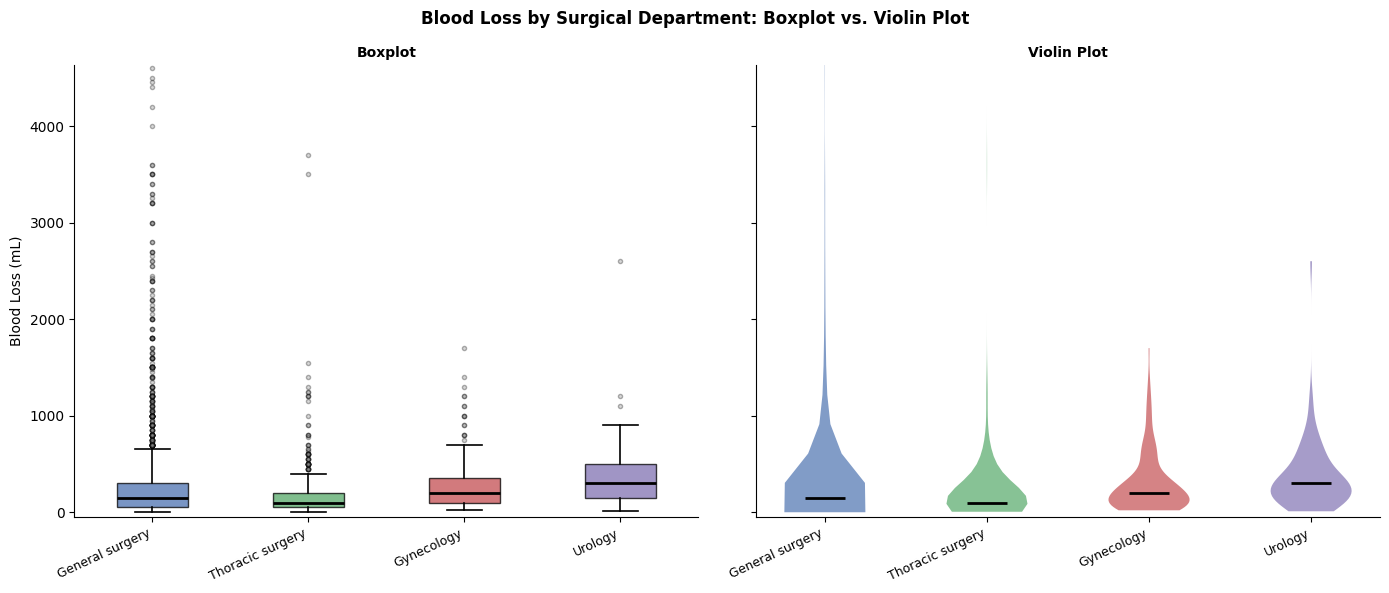

Blood loss summary by department (mL):
Department                    n   Median              IQR       Max
─────────────────────────────────────────────────────────────────
General surgery           3,091      150  50–300 mL      30100
Thoracic surgery            639      100  50–200 mL       8150
Gynecology                  175      200  100–350 mL       1700
Urology                      82      300  150–500 mL       2600


In [6]:
# Top 6 departments by case volume
top_depts = cases['department'].value_counts().head(6).index.tolist()
dept_df   = cases[cases['department'].isin(top_depts)].copy()

# Cap blood loss at 99th percentile for legibility
ebl_cap = dept_df['intraop_ebl'].quantile(0.99)
dept_df['ebl_capped'] = dept_df['intraop_ebl'].clip(upper=ebl_cap).dropna()

# Shorten department names for axis labels
dept_short = {
    d: d.replace(' Surgery', '').replace('Orthopedic', 'Ortho').replace('Thoracic', 'Thoracic')
    for d in top_depts
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle('Blood Loss by Surgical Department: Boxplot vs. Violin Plot',
             fontsize=12, fontweight='bold')

palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']

dept_data  = [dept_df[dept_df['department'] == d]['intraop_ebl'].dropna().values
              for d in top_depts]
dept_names = [dept_short[d] for d in top_depts]

# ── Boxplot ───────────────────────────────────────────────────────────────────
ax = axes[0]
bp = ax.boxplot(dept_data, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='grey',
                                alpha=0.3, markersize=3, linestyle='none'),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticks(range(1, len(top_depts) + 1))
ax.set_xticklabels(dept_names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Blood Loss (mL)', fontsize=10)
ax.set_title('Boxplot', fontsize=10, fontweight='bold')
ax.set_ylim(-50, ebl_cap * 1.05)
ax.spines[['top', 'right']].set_visible(False)

# ── Violin plot ───────────────────────────────────────────────────────────────
ax = axes[1]
parts = ax.violinplot(dept_data, positions=range(1, len(top_depts) + 1),
                      showmedians=True, showextrema=False)
for pc, color in zip(parts['bodies'], palette):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(1, len(top_depts) + 1))
ax.set_xticklabels(dept_names, rotation=25, ha='right', fontsize=9)
ax.set_title('Violin Plot', fontsize=10, fontweight='bold')
ax.set_ylim(-50, ebl_cap * 1.05)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Summary statistics
print("Blood loss summary by department (mL):")
print(f"{'Department':<25} {'n':>5}  {'Median':>7}  {'IQR':>15}  {'Max':>8}")
print('─' * 65)
for d, name in zip(top_depts, dept_names):
    s = cases[cases['department'] == d]['intraop_ebl'].dropna()
    print(f"{name:<25} {len(s):>5,}  {s.median():>7.0f}  "
          f"{s.quantile(0.25):.0f}–{s.quantile(0.75):.0f} mL   {s.max():>8.0f}")

### What the violin reveals that the boxplot hides

The boxplot (left panel) shows median and IQR for each department — useful for comparing typical blood loss and spread. But it conceals the **shape** of the distribution within each group.

The violin plot (right panel) reveals:

- **Zero-inflation:** Several departments have a large mass at zero (minimal blood loss) — visible as a wide bulge at the bottom of the violin. This is clinically expected for laparoscopic and endoscopic procedures. The boxplot would show Q1 = 0 and Q3 = 50, obscuring the true bimodal structure.

- **Asymmetry within groups:** The violin for some departments is much wider at the bottom (most cases have low blood loss) with a thin tail extending upward (rare high-loss cases). The boxplot's whisker hints at this but the violin quantifies it.

- **Genuine distributional differences between departments:** Transplant and hepatic surgery cases have wide, tall violins — reflecting both higher median blood loss and genuine high variability from case to case. Laparoscopic general surgery departments have compact violins tightly clustered near zero.

**When to use which:**
- Boxplot: quick side-by-side comparison of location and spread across many groups (>6)
- Violin: deeper inspection of distributional shape, especially when normality or symmetry cannot be assumed — which is almost always in perioperative data